# 02 - Method Comparison & Results

This notebook reads the metrics produced by `python main.py` (`results/metrics.csv` and `results/rating_metrics.csv`) and turns them into the comparison tables and figures used in the report and slide deck.

**Evaluation protocol.** Per-user stratified 80/20 split; an item is *relevant* for a user if it appears in their test set with rating >= 4.0. Top-N recommendations (K=10) are generated from training data only, excluding items already seen. Metrics are averaged over the 599 users that have at least one relevant test item.

**Metrics.**
- *Accuracy / ranking*: Precision@K, Recall@K, NDCG@K, MRR@K, Hit-Rate@K.
- *Beyond-accuracy*: catalog coverage (fraction of catalog ever recommended), novelty (mean self-information -log2 P(item)), intra-list diversity (mean pairwise 1-cosine over genre vectors).
- *Rating prediction* (models with `predict_score`): RMSE, MAE.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src import config

FIG_DIR = config.RESULTS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams["figure.dpi"] = 110

metrics = pd.read_csv(config.RESULTS_DIR / "metrics.csv", index_col="model")
rating = pd.read_csv(config.RESULTS_DIR / "rating_metrics.csv", index_col="model")
metrics

,precision@k,recall@k,ndcg@k,mrr@k,hit_rate@k,catalog_coverage,novelty@k,diversity@k,n_users_evaluated,k
model,,,,,,,,,,
user_user_cf,0.162604,0.145002,0.218907,0.393078,0.647746,0.030968,2.186863,0.752629,599,10
item_item_cf,0.155259,0.126412,0.210826,0.401758,0.644407,0.086220,2.804430,0.719722,599,10
most_popular,0.121703,0.104251,0.161180,0.311591,0.574290,0.006350,1.664438,0.758260,599,10
matrix_factorization,0.056260,0.041432,0.072393,0.167870,0.355593,0.049014,3.412941,0.780978,599,10
highest_average,0.046411,0.033983,0.061872,0.150594,0.300501,0.003787,3.387811,0.664025,599,10
content_based,0.006845,0.004728,0.007634,0.018711,0.063439,0.340648,7.282880,0.084986,599,10
random,0.001336,0.000650,0.001356,0.003747,0.013356,0.489473,7.567267,0.802035,599,10


## 1. Ranking accuracy

NDCG@10 and Precision@10 by method. The two neighbourhood CF methods lead, the most-popular baseline is a strong third, and — notably — RMSE-trained matrix factorization trails on ranking.

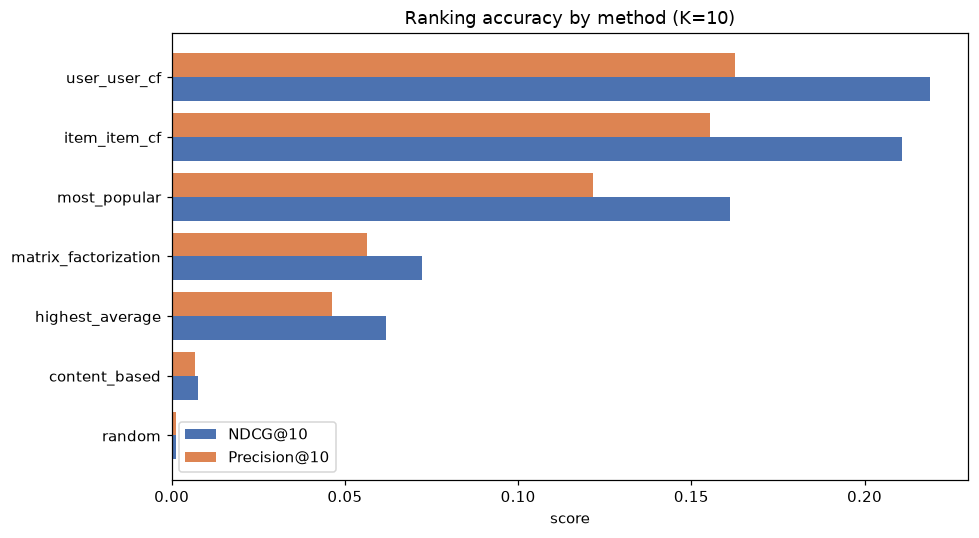

In [2]:
acc = metrics.sort_values("ndcg@k", ascending=True)
fig, ax = plt.subplots(figsize=(9, 5))
y = np.arange(len(acc))
ax.barh(y - 0.2, acc["ndcg@k"], height=0.4, label="NDCG@10", color="#4C72B0")
ax.barh(y + 0.2, acc["precision@k"], height=0.4, label="Precision@10", color="#DD8452")
ax.set_yticks(y)
ax.set_yticklabels(acc.index)
ax.set_xlabel("score")
ax.set_title("Ranking accuracy by method (K=10)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "accuracy_comparison.png", bbox_inches="tight")
plt.show()

## 2. The accuracy vs. coverage trade-off

Accuracy is not the whole story. Plotting NDCG against catalog coverage shows the central tension: the most accurate methods recommend from a tiny slice of the catalog, while high-coverage methods (content-based, random) are inaccurate. A good production system has to choose a point on this frontier, not just maximize accuracy.

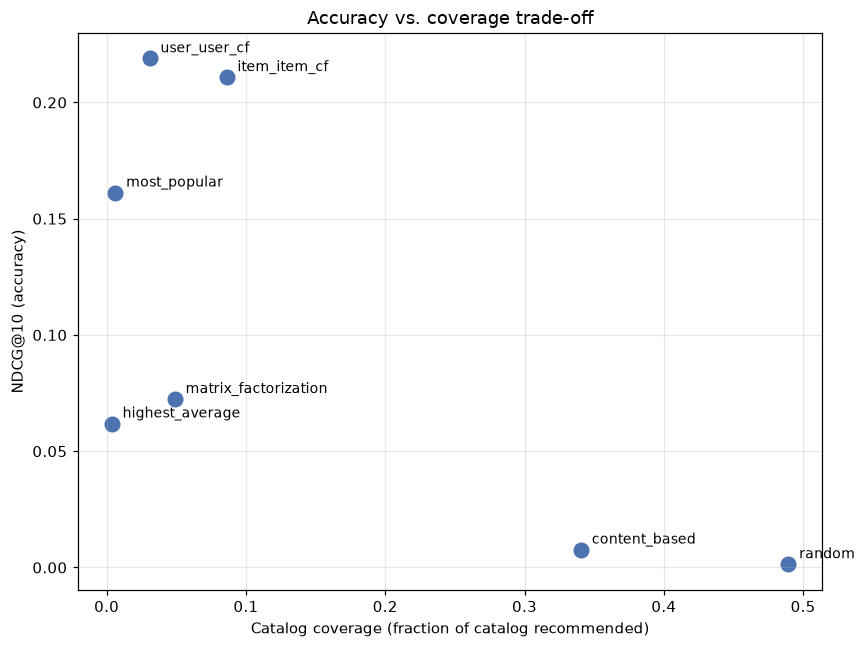

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(metrics["catalog_coverage"], metrics["ndcg@k"], s=90, color="#4C72B0")
for name, row in metrics.iterrows():
    ax.annotate(name, (row["catalog_coverage"], row["ndcg@k"]),
                textcoords="offset points", xytext=(7, 4), fontsize=9)
ax.set_xlabel("Catalog coverage (fraction of catalog recommended)")
ax.set_ylabel("NDCG@10 (accuracy)")
ax.set_title("Accuracy vs. coverage trade-off")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "accuracy_vs_coverage.png", bbox_inches="tight")
plt.show()

## 3. Novelty and diversity

Novelty rises as methods move away from the popular head; diversity captures how spread-out a single recommendation list is across genres. Content-based is the clearest outlier: very high novelty but very *low* intra-list diversity, because it keeps recommending items from the user's single favourite genre cluster.

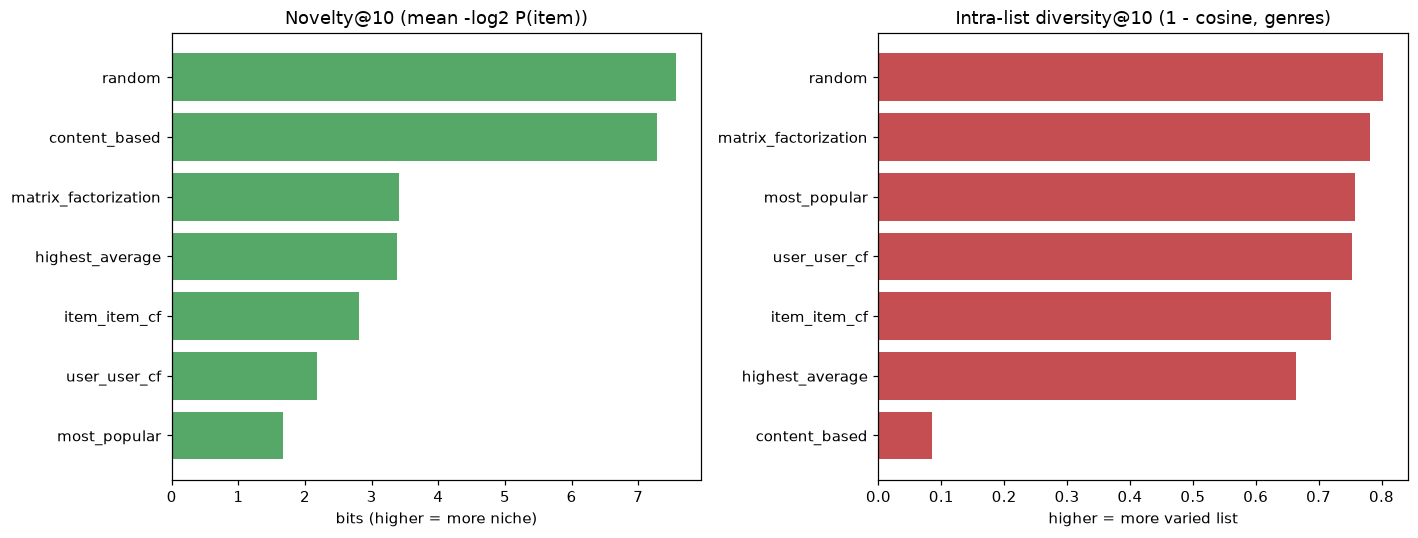

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
nov = metrics.sort_values("novelty@k")
axes[0].barh(nov.index, nov["novelty@k"], color="#55A868")
axes[0].set_title("Novelty@10 (mean -log2 P(item))")
axes[0].set_xlabel("bits (higher = more niche)")

div = metrics.sort_values("diversity@k")
axes[1].barh(div.index, div["diversity@k"], color="#C44E52")
axes[1].set_title("Intra-list diversity@10 (1 - cosine, genres)")
axes[1].set_xlabel("higher = more varied list")

fig.tight_layout()
fig.savefig(FIG_DIR / "novelty_diversity.png", bbox_inches="tight")
plt.show()

## 4. Rating prediction: where matrix factorization wins

MF is weak at top-N ranking but it is the *best* model at predicting the actual rating a user would give — the task it was trained for. This is the key nuance: "MF doesn't work" is wrong; **MF optimizes RMSE, which is not the same objective as ranking the top-10**. A production ranking system would switch MF to an implicit/ranking objective (BPR, ALS, logistic MF).

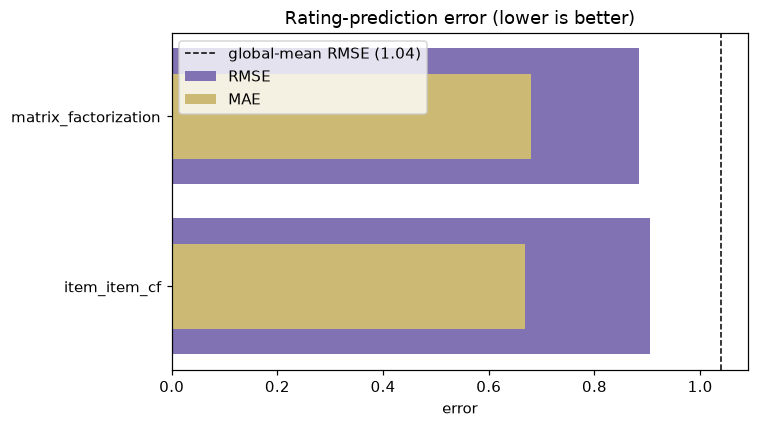

,rmse,mae,n_predictions
model,,,
matrix_factorization,0.884713,0.679026,20168
item_item_cf,0.904670,0.668984,17256


In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
r = rating.sort_values("rmse", ascending=False)
ax.barh(r.index, r["rmse"], color="#8172B3", label="RMSE")
ax.barh(r.index, r["mae"], color="#CCB974", height=0.5, label="MAE")
ax.axvline(1.0386, color="k", ls="--", lw=1, label="global-mean RMSE (1.04)")
ax.set_title("Rating-prediction error (lower is better)")
ax.set_xlabel("error")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "rating_prediction.png", bbox_inches="tight")
plt.show()
rating

## 5. Ablation: TF-IDF vs. raw genre vectors

The content-based model represents each movie by a vector over its **genres**
(each genre is a token; one movie is a "document"). Here we ask whether the
TF-IDF weighting actually helps, versus plain **raw genre vectors** (L2-normalized
0/1 presence, every genre weighted equally).

Because each genre appears at most once per movie, the term-frequency is always 1,
so the only thing TF-IDF changes is the **IDF** weight: common genres (Drama,
Comedy) are down-weighted and rare, distinctive ones (Film-Noir, Western, IMAX)
are up-weighted. We measure both variants with the *same* fixed genre space for
the diversity metric, so the comparison is fair.

In [6]:
from src.data_loading import load_ratings, load_items, train_test_split_ratings
from src.content_based import ContentBasedRecommender
from src.evaluation import evaluate_model

_r = load_ratings(); _m = load_items()
_tr, _te = train_test_split_ratings(_r, test_size=0.2)

# Fixed reference space for the diversity metric so both variants are scored identically.
_ref = ContentBasedRecommender(use_tfidf=True).fit(_tr, _m)
_divfeat = (_ref.item_features_, _ref.item_id_to_index_)

rows = []
for label, use in [("TF-IDF genres", True), ("Raw genre vectors", False)]:
    cb = ContentBasedRecommender(use_tfidf=use).fit(_tr, _m)
    res = evaluate_model(cb, _tr, _te, k=10, diversity_features=_divfeat)
    rows.append({
        "variant": label,
        "precision@10": res["precision@k"],
        "ndcg@10": res["ndcg@k"],
        "hit_rate@10": res["hit_rate@k"],
        "coverage": res["catalog_coverage"],
        "novelty": res["novelty@k"],
        "diversity": res["diversity@k"],
    })

ablation = pd.DataFrame(rows).set_index("variant")
ablation.to_csv(config.RESULTS_DIR / "ablation_tfidf.csv")
ablation.style.format("{:.4f}")


,precision@10,ndcg@10,hit_rate@10,coverage,novelty,diversity
variant,,,,,,
TF-IDF genres,0.0068,0.0076,0.0634,0.3406,7.2829,0.0850
Raw genre vectors,0.0058,0.0056,0.0534,0.3520,7.2883,0.0746


## 6. Discussion

- **Neighbourhood CF wins top-N.** User-user (NDCG 0.219) and item-item (0.211) lead. User-user edges ahead because the user axis is denser (median 70 ratings/user) than the item axis (median 3/item), so user neighbourhoods are more reliable on this data.
- **Popularity is a strong but narrow baseline.** Most-popular reaches NDCG 0.161 while touching only ~0.6% of the catalog — pure popularity bias. Any "win" over it must be judged together with coverage/novelty.
- **Matrix factorization: right tool, wrong metric.** Lowest RMSE (0.885, ~15% better than the global-mean baseline) but weak top-N, because squared-error training is not a ranking objective. Future work: BPR / implicit-feedback MF.
- **Content-based trades accuracy for novelty.** Lowest accuracy but the highest novelty and (by design) low intra-list diversity. It is the natural fallback for cold/long-tail items that CF cannot score — motivating a hybrid.
- **TF-IDF beats raw genre vectors, modestly.** IDF-weighting distinctive genres lifts NDCG from 0.0056 to 0.0076 (~36% relative) and hit-rate from 0.053 to 0.063, at a tiny cost in coverage. The effect is small because there are only ~20 genre tokens and term-frequency is always 1, so only the IDF term is active — richer text (tags, synopsis) would give TF-IDF more to work with.
- **Sparsity handling worked.** The shrinkage + min-support safeguards kept item-item CF stable despite the median of 3 ratings/item; without the ranking fix (raw weighted sum instead of normalized prediction) CF collapsed to near-random, a concrete sparsity lesson.

**Limitations:** single random split (no cross-validation / temporal split); relevance threshold fixed at 4.0; diversity measured only over genres; cold-start users/items not separately analysed. These are the natural next steps.